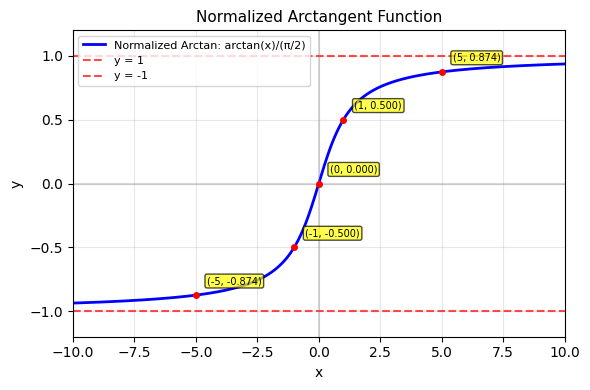

In [6]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# 创建输入数据
x = np.linspace(-10, 10, 1000)

# 计算反正切函数，并归一化到[-1, 1]
# arctan(x) 的值域是 (-π/2, π/2)，所以除以 π/2 得到 [-1, 1]
y = np.arctan(x) / (np.pi / 2)

# 绘制图形 - 调整图像大小
plt.figure(figsize=(6, 4))  # 从 (10, 6) 改为 (6, 4)
plt.plot(x, y, 'b-', linewidth=2, label='Normalized Arctan: arctan(x)/(π/2)')
plt.axhline(y=1, color='r', linestyle='--', alpha=0.7, label='y = 1')
plt.axhline(y=-1, color='r', linestyle='--', alpha=0.7, label='y = -1')
plt.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
plt.axvline(x=0, color='gray', linestyle='-', alpha=0.3)

plt.grid(True, alpha=0.3)
plt.xlabel('x', fontsize=10)  # 稍微减小字体
plt.ylabel('y', fontsize=10)
plt.title('Normalized Arctangent Function', fontsize=11)  # 缩短标题并减小字体
plt.legend(fontsize=8)  # 减小图例字体
plt.xlim(-10, 10)
plt.ylim(-1.2, 1.2)

# 添加一些关键点的标注
key_points_x = [-5, -1, 0, 1, 5]
key_points_y = [np.arctan(x_val) / (np.pi / 2) for x_val in key_points_x]
for i, (x_val, y_val) in enumerate(zip(key_points_x, key_points_y)):
    plt.plot(x_val, y_val, 'ro', markersize=4)  # 减小点的大小
    plt.annotate(f'({x_val}, {y_val:.3f})', 
                xy=(x_val, y_val), 
                xytext=(8, 8),  # 减小偏移
                textcoords='offset points',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='yellow', alpha=0.7),
                fontsize=7)  # 减小标注字体

plt.tight_layout()
plt.show()

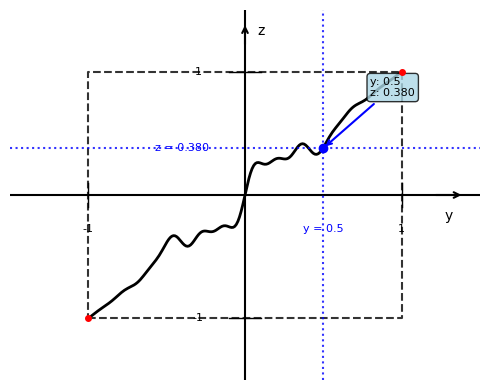

当输入 y = 0.5 时，输出 z = 0.380


In [10]:
import matplotlib.pyplot as plt
import numpy as np

# 创建图形和轴 - 调整图像大小
fig, ax = plt.subplots(1, 1, figsize=(5, 4))  # 从 (8, 6) 改为 (5, 4)

# 设置坐标轴
ax.axhline(y=0, color='black', linewidth=1.5)  # x轴
ax.axvline(x=0, color='black', linewidth=1.5)  # y轴

# 设置坐标轴范围
ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)

# 添加箭头到坐标轴
ax.annotate('', xy=(1.4, 0), xytext=(1.2, 0), 
            arrowprops=dict(arrowstyle='->', color='black', lw=1.5))
ax.annotate('', xy=(0, 1.4), xytext=(0, 1.2),
            arrowprops=dict(arrowstyle='->', color='black', lw=1.5))

# 添加坐标轴标签
ax.text(1.3, -0.2, 'y', fontsize=10, ha='center')  # 减小字体
ax.text(0.1, 1.3, 'z', fontsize=10, ha='center')

# 绘制虚线框（定义域和值域的边界）
ax.plot([-1, 1, 1, -1, -1], [-1, -1, 1, 1, -1], 
        'k--', linewidth=1.5, alpha=0.8)

# 添加刻度标记
ax.plot([-1, -1], [-0.1, 0.1], 'k-', linewidth=1)  # -1标记
ax.plot([1, 1], [-0.1, 0.1], 'k-', linewidth=1)    # 1标记
ax.plot([-0.1, 0.1], [-1, -1], 'k-', linewidth=1)  # -1标记
ax.plot([-0.1, 0.1], [1, 1], 'k-', linewidth=1)    # 1标记

# 添加刻度标签
ax.text(-1, -0.3, '-1', fontsize=8, ha='center')  # 减小字体
ax.text(1, -0.3, '1', fontsize=8, ha='center')
ax.text(-0.3, -1, '-1', fontsize=8, ha='center', va='center')
ax.text(-0.3, 1, '1', fontsize=8, ha='center', va='center')

# 创建经过(-1,-1)和(1,1)且有平滑正弦噪声的函数
t = np.linspace(-1, 1, 200)

# 基础线性函数 z = y
base_curve = t

# 添加平滑的正弦噪声
# 使用多个频率的正弦波组合，创建自然的波动
noise = (0.15 * np.sin(3 * np.pi * t) + 
         0.08 * np.sin(7 * np.pi * t) + 
         0.04 * np.sin(12 * np.pi * t))

# 端点衰减权重，确保在(-1,-1)和(1,1)处噪声为0
weight = np.sin(np.pi * (t + 1) / 2)**2  # 在端点为0，中间为1

# 最终曲线
z = base_curve + noise * weight

# 确保曲线严格经过端点
z[0] = -1  # 确保经过(-1, -1)
z[-1] = 1  # 确保经过(1, 1)

# 绘制曲线
ax.plot(t, z, 'k-', linewidth=2)  # 稍微减细线条

# 标记特殊点
ax.plot([-1, 1], [-1, 1], 'ro', markersize=4, zorder=5)  # 减小点的大小

# 计算并标注输入0.5对应的输出
input_val = 0.5
# 找到最接近0.5的索引
idx = np.argmin(np.abs(t - input_val))
output_val = z[idx]

# 绘制输入0.5的垂直线和水平线
ax.axvline(x=input_val, color='blue', linestyle=':', alpha=0.8, linewidth=1.5)
ax.axhline(y=output_val, color='blue', linestyle=':', alpha=0.8, linewidth=1.5)

# 标记输入输出点
ax.plot(input_val, output_val, 'bo', markersize=6, zorder=5)

# 添加输入输出标注
ax.text(input_val, -0.3, f'y = {input_val}', fontsize=8, ha='center', color='blue')
ax.text(-0.4, output_val, f'z = {output_val:.3f}', fontsize=8, ha='center', va='center', color='blue')

# 添加箭头指向该点
ax.annotate(f'y: {input_val}\nz: {output_val:.3f}', 
            xy=(input_val, output_val), 
            xytext=(0.8, 0.8),
            textcoords='data',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightblue', alpha=0.8),
            fontsize=8,
            arrowprops=dict(arrowstyle='->', color='blue', lw=1.5))

# 移除默认的刻度
ax.set_xticks([])
ax.set_yticks([])

# 移除边框
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)

# 设置背景色
ax.set_facecolor('white')

plt.tight_layout()
plt.show()

print(f"当输入 y = {input_val} 时，输出 z = {output_val:.3f}")

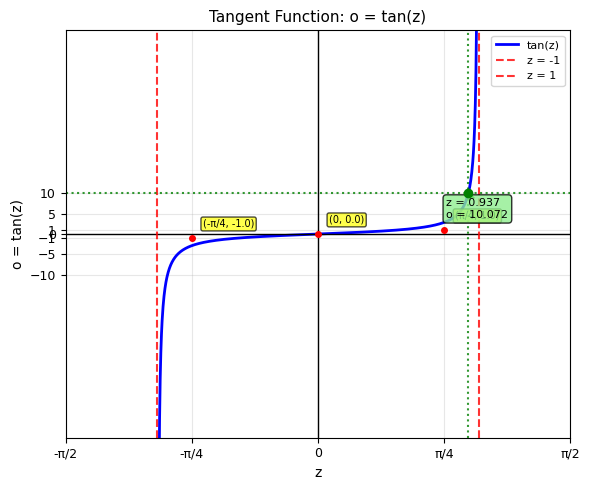

当输入 z = 0.937 时，输出 o = 10.072067


In [7]:
import matplotlib.pyplot as plt
import numpy as np

# 创建图形和轴 - 调整图像大小
fig, ax = plt.subplots(1, 1, figsize=(6, 5))  # 从 (10, 8) 改为 (6, 5)

# 创建 x 值，避免在 ±π/2 处的奇点
x = np.linspace(-1 + 0.01, 1 - 0.01, 1000)

# 计算正切函数
y = np.tan(x * np.pi / 2)

# 绘制正切函数
ax.plot(x, y, 'b-', linewidth=2, label='tan(z)')  # 稍微减细线条

# 设置坐标轴
ax.axhline(y=0, color='black', linewidth=1)  # x轴
ax.axvline(x=0, color='black', linewidth=1)  # y轴

# 添加垂直渐近线
ax.axvline(x=-1, color='red', linestyle='--', alpha=0.8, linewidth=1.5, label='z = -1')
ax.axvline(x=1, color='red', linestyle='--', alpha=0.8, linewidth=1.5, label='z = 1')

# 设置坐标轴范围
ax.set_xlim(-1 - 0.2, 1 + 0.2)
ax.set_ylim(-50, 50)

# 添加网格
ax.grid(True, alpha=0.3)

# 设置 x 轴刻度
x_ticks = [-np.pi/2, -np.pi/4, 0, np.pi/4, np.pi/2]
x_labels = ['-π/2', '-π/4', '0', 'π/4', 'π/2']
ax.set_xticks(x_ticks)
ax.set_xticklabels(x_labels, fontsize=9)  # 减小刻度字体

# 设置 y 轴刻度
ax.set_yticks([-10, -5, -1, 0, 1, 5, 10])
ax.tick_params(axis='y', labelsize=9)  # 减小y轴刻度字体

# 添加标签和标题
ax.set_xlabel('z', fontsize=10)  # 更改为z
ax.set_ylabel('o = tan(z)', fontsize=10)  # 更改为o
ax.set_title('Tangent Function: o = tan(z)', fontsize=11)  # 缩短标题并减小字体

# 添加图例
ax.legend(fontsize=8)  # 减小图例字体

# 标记一些关键点
key_points_x = [-np.pi/4, 0, np.pi/4]
key_points_y = [np.tan(x_val) for x_val in key_points_x]
ax.plot(key_points_x, key_points_y, 'ro', markersize=4, zorder=5)  # 减小点的大小

# 添加关键点的标注
for x_val, y_val, label in zip(key_points_x, key_points_y, ['-π/4', '0', 'π/4']):
    ax.annotate(f'({label}, {y_val:.1f})', 
                xy=(x_val, y_val), 
                xytext=(8, 8),  # 减小偏移
                textcoords='offset points',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='yellow', alpha=0.7),
                fontsize=7)  # 减小标注字体

# 添加输入0.380的标注
input_z = 0.937
output_o = np.tan(input_z * np.pi / 2)

# 绘制输入0.380的垂直线和水平线
ax.axvline(x=input_z, color='green', linestyle=':', alpha=0.8, linewidth=1.5)
ax.axhline(y=output_o, color='green', linestyle=':', alpha=0.8, linewidth=1.5)

# 标记输入输出点
ax.plot(input_z, output_o, 'go', markersize=6, zorder=5)

# 添加输入输出标注
ax.annotate(f'z = {input_z}\no = {output_o:.3f}', 
            xy=(input_z, output_o), 
            xytext=(0.8, 4),  # 调整标注位置
            textcoords='data',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightgreen', alpha=0.8),
            fontsize=8,
            arrowprops=dict(arrowstyle='->', color='green', lw=1.5))

plt.tight_layout()
plt.show()

print(f"当输入 z = {input_z} 时，输出 o = {output_o:.6f}")

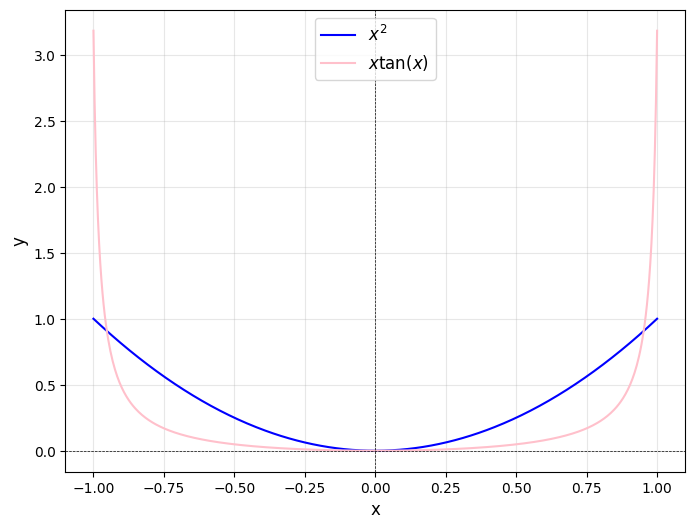

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# 定义x范围
x = np.linspace(-1, 1, 500)

# 定义函数
y2 = x**2
# y4 = x**4
# y6 = x**6
# y7 = np.exp(x) - 1
# y8 = np.exp(abs(2 * x)) - 1
# y9 = np.tan(x * np.pi / 2) * np.sin(x)
# y10 = np.tan(x * np.pi / 2) * (np.sin(x * np.pi / 2)) * 0.1
y11 = np.tan(x * np.pi / 2 * 0.98) * (x) * 0.1

# 绘制图像
plt.figure(figsize=(8, 6))
plt.plot(x, y2, label=r"$x^2$", color="blue")
# plt.plot(x, y4, label=r"$x^4$", color="green")
# plt.plot(x, y6, label=r"$x^6$", color="red")
# plt.plot(x, y7, label=r"$e^x-1$", color="purple")
# plt.plot(x, y8, label=r"$e^{2x}-1$", color="orange")
# # plt.plot(x, y9, label=r"$\tan(x)$", color="brown")
# plt.plot(x, y10, label=r"$\tan(x)\sin(x)$", color="gray")
plt.plot(x, y11, label=r"$x\tan(x)$", color="pink")

# 添加图例和标题
# plt.title("Graphs of $x^2$, $x^4$, and $x^6$ on [-1, 1]", fontsize=14)
plt.xlabel("x", fontsize=12)
plt.ylabel("y", fontsize=12)
plt.axhline(0, color="black", linewidth=0.5, linestyle="--")
plt.axvline(0, color="black", linewidth=0.5, linestyle="--")
plt.legend(fontsize=12)
plt.grid(alpha=0.3)

# 显示图像
plt.show()

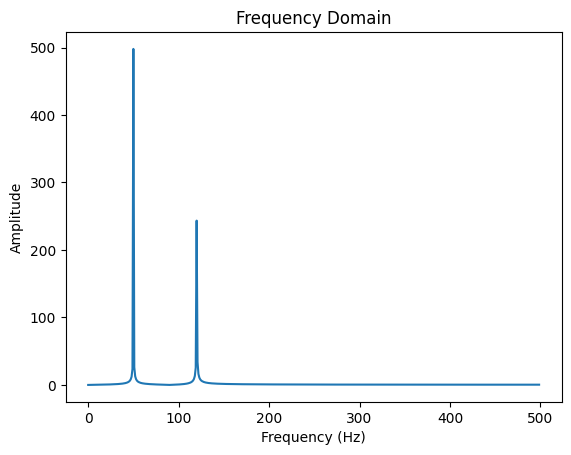

In [33]:
import torch

# 创建一个信号（时域）
t = torch.linspace(0, 1, 1000)  # 时间
signal = torch.sin(2 * torch.pi * 50 * t) + 0.5 * torch.sin(2 * torch.pi * 120 * t)  # 50Hz 和 120Hz 的正弦波叠加

# 计算傅里叶变换（频率域）
fft_signal = torch.fft.fft(signal)

# 计算频率分量的幅度
amplitude = torch.abs(fft_signal)

# 频率轴
frequencies = torch.fft.fftfreq(signal.size(0), d=(t[1] - t[0]))

# 可视化
import matplotlib.pyplot as plt
plt.plot(frequencies[:500], amplitude[:500])  # 只显示正频率分量
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.title("Frequency Domain")
plt.show()

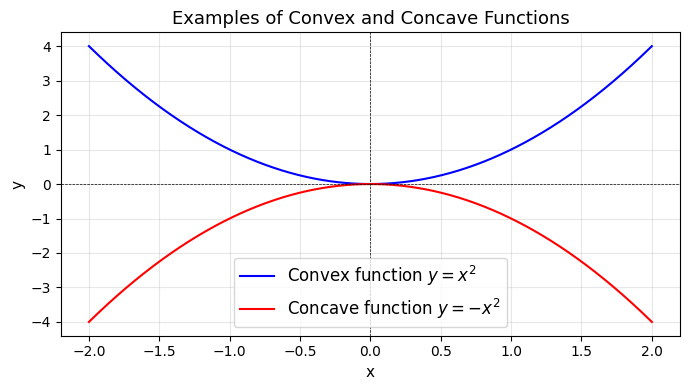

Convex function second difference: 0.006399999743897489 1.280512153640954e-06
Concave function second difference: -0.006399999743897489 -1.280512153640954e-06


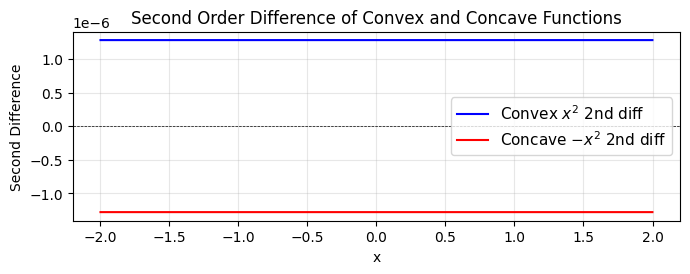

In [21]:
import numpy as np
import torch
import matplotlib.pyplot as plt

# Define the variable
x = np.linspace(-2, 2, 5000)

# Convex function: y = x^2
y_convex = x**2

# Concave function: y = -x^2
y_concave = -x**2

plt.figure(figsize=(7, 4))
plt.plot(x, y_convex, label='Convex function $y = x^2$', color='blue')
plt.plot(x, y_concave, label='Concave function $y = -x^2$', color='red')
plt.axhline(0, color='black', linewidth=0.5, linestyle='--')
plt.axvline(0, color='black', linewidth=0.5, linestyle='--')
plt.legend(fontsize=12)
plt.title('Examples of Convex and Concave Functions', fontsize=13)
plt.xlabel('x', fontsize=11)
plt.ylabel('y', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 计算二阶差分
y_convex_diff2 = torch.diff(torch.tensor(y_convex), n=2)
y_concave_diff2 = torch.diff(torch.tensor(y_concave), n=2)

print("Convex function second difference:", np.sum(y_convex_diff2.numpy()), np.mean(y_convex_diff2.numpy()))
print("Concave function second difference:", np.sum(y_concave_diff2.numpy()), np.mean(y_concave_diff2.numpy()))

# 可视化二阶差分结果
plt.figure(figsize=(7, 3))
plt.plot(x[1:-1], y_convex_diff2.numpy(), label='Convex $x^2$ 2nd diff', color='blue')
plt.plot(x[1:-1], y_concave_diff2.numpy(), label='Concave $-x^2$ 2nd diff', color='red')
plt.axhline(0, color='black', linewidth=0.5, linestyle='--')
plt.legend(fontsize=11)
plt.title('Second Order Difference of Convex and Concave Functions', fontsize=12)
plt.xlabel('x', fontsize=10)
plt.ylabel('Second Difference', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
grid = 10000

x = torch.linspace(-0.9, 0.9, grid, requires_grad=True).unsqueeze(0).unsqueeze(-1)
output = x ** 2

# 计算步长
h = (0.9 - (-0.9)) / (grid - 1)  # 步长

# 标准化的二阶差分 (近似二阶导数)
diff2 = torch.diff(output, n=2, dim=1) / (h * h)

# 主动鼓励凸性
convex_mean = torch.mean(diff2)
convex_sum = torch.sum(diff2)

print(f"Convex Mean: {convex_mean.item()}, Convex Sum: {convex_sum.item()}")

Convex Mean: 1.9996991157531738, Convex Sum: 19992.9921875
